In [55]:
# Importamos librerias
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
import pickle

# Objetivo

Definir un modelo que haga la predicción de cancelaciones de reservas hoteleras a partir de datos históricos. En concreto, se pretende analizar si una reserva ya realizada será finalmente cancelada o no, utilizando la información disponible en el momento de la reserva. El target "is_cancelled"( 1= si la reserva se cancela), y (0= la reserva no se cancela).


In [44]:
# Carga del dataset limpio
df = pd.read_csv(r"C:\Users\tifaw\OneDrive\Desktop\BOOTCAMP_DATASCIENCE\REPOSITORIO_GIT\Proyectos\ML_project_fatima\src\data\hotel_bookings_cleaned.csv")
df.head(5)

,is_canceled,lead_time,arrival_date_month,country,market_segment,distribution_channel,is_repeated_guest,booking_changes,agent,days_in_waiting_list,...,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Contract,customer_type_Group,customer_type_Transient,customer_type_Transient-Party,total_guests,total_stays,room_changed,had_prev_cancellations
0,0,7,7,1,1,1,0,0,0.0,0,...,False,False,False,False,True,False,1.0,1,1,0
1,0,13,7,1,2,2,0,0,304.0,0,...,False,False,False,False,True,False,1.0,1,0,0
2,0,14,7,1,3,3,0,0,240.0,0,...,False,False,False,False,True,False,2.0,2,0,0
3,0,0,7,2,1,1,0,0,0.0,0,...,False,False,False,False,True,False,2.0,2,0,0
4,0,9,7,2,1,1,0,0,303.0,0,...,False,False,False,False,True,False,2.0,2,0,0


In [46]:
# 2. Verificamos los datos 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85590 entries, 0 to 85589
Data columns (total 31 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   is_canceled                    85590 non-null  int64  
 1   lead_time                      85590 non-null  int64  
 2   arrival_date_month             85590 non-null  int64  
 3   country                        85590 non-null  int64  
 4   market_segment                 85590 non-null  int64  
 5   distribution_channel           85590 non-null  int64  
 6   is_repeated_guest              85590 non-null  int64  
 7   booking_changes                85590 non-null  int64  
 8   agent                          85590 non-null  float64
 9   days_in_waiting_list           85590 non-null  int64  
 10  adr                            85590 non-null  float64
 11  required_car_parking_spaces    85590 non-null  int64  
 12  total_of_special_requests      85590 non-null 

2. División y escalado de datos

In [47]:
# 1. Separar X (features) e y (target)
X = df.drop('is_canceled', axis=1)
y = df['is_canceled']

# 2. División Train (80%) y Test(20%)
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.20,
                                                    random_state=42,
                                                    stratify= y) # con stratify hago que el % de cancelaciones en test y train se a la misma.

# 3. Escalado
# from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [48]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(68472, 30)
(17118, 30)
(68472,)
(17118,)


3. Entrenamientos de Modelos

In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay

1. Modelo 1: LogisticRegression

In [50]:
# 1. Logistic Regression (Regresión logística)
lr_model = LogisticRegression(max_iter= 1000) #max_iter, fijamos maximo de iteracion para que el modelo encuentre la mejor solución
lr_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

--- MÉTRICAS DE REGRESIÓN LOGÍSTICA ---
              precision    recall  f1-score   support

           0       0.80      0.94      0.86     12350
           1       0.71      0.39      0.50      4768

    accuracy                           0.78     17118
   macro avg       0.75      0.66      0.68     17118
weighted avg       0.77      0.78      0.76     17118



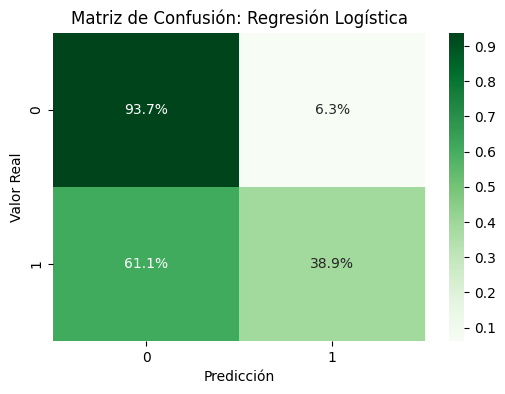

In [56]:
# Realizamos las Predicciones de regresión logística
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. El modelo hace sus predicciones sobre X_test
y_pred_lr = lr_model.predict(X_test)

# 2. Sacamos las métricas para evaluar el modelo
print("--- MÉTRICAS DE REGRESIÓN LOGÍSTICA ---")
print(classification_report(y_test, y_pred_lr))

# 3. Dibujamos la Matriz de Confusión para ver los aciertos y fallos visualmente

cm = confusion_matrix(y_test, y_pred_lr, normalize='true')
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(cm,
            annot=True,
            fmt='.1%',
            cmap='Greens')
plt.title('Matriz de Confusión: Regresión Logística')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()


Conclusión:<br>
 1= sí cancela <br>
-Recall: el modelo no es muy bueno ya que solo detecta 39% de las cancelaciones.<br>
-precision: cuando el modelo dice que esta reserva se va a cancelar, acierta el 71% de las veces. mi modelo es poco predictivo.<br>
 0= No cancela<br>
-recall:el modelo es muy bueno detectando las reservas  que no se cancela, acierta un 94%. esto se debe a que el dataset esta desbalanceado.<br>
-Conclusion: al estar el dataset desbalanceado, mi modelo actual tiene dificultad para detectar cancelaciones reales, como podemos ver en la matriz de confusión, se le escapan 2912 cancelaciones reales que no ha detectado.<br>
Mi modelo no es muy buen predictor de las cancelaciones.<br>


Modelo 2: Random Forest

In [57]:
# Random Forest model
# Usamos 100 árboles para empezar
rf_model = RandomForestClassifier(n_estimators=100,
                                max_depth=10,
                                  random_state=42)
# Entrenamos el modelo
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

Cross_validation

In [58]:
# Validación cruzada para confirmar que max_depth=10 eliminó el overfitting
from sklearn.model_selection import cross_val_score
# Evaluamos recall
cv_rf = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='recall')

print("--- RF: VALIDACIÓN CRUZADA (RECALL) ---")
print(f"Recall medio: {cv_rf.mean():.4f}")
print(f"Variabilidad (Std): {cv_rf.std():.4f}")
#La bajísima variabilidad (0.0104) demuestra que el modelo ha generalizado bien y es fiable.

--- RF: VALIDACIÓN CRUZADA (RECALL) ---
Recall medio: 0.4359
Variabilidad (Std): 0.0104


--- MÉTRICAS DE RANDOM FOREST ---
              precision    recall  f1-score   support

           0       0.82      0.95      0.88     12350
           1       0.78      0.45      0.57      4768

    accuracy                           0.81     17118
   macro avg       0.80      0.70      0.73     17118
weighted avg       0.81      0.81      0.79     17118



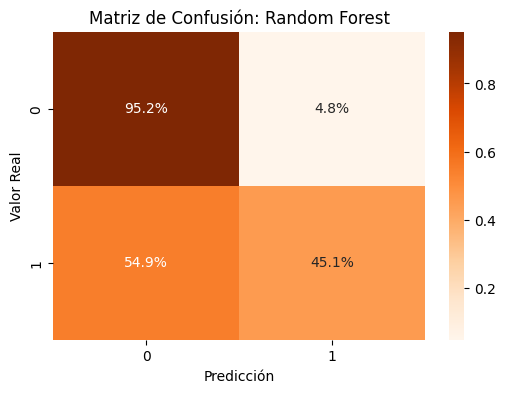

In [59]:
#Realizamos las Predicciones del random forest
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. El modelo hace sus predicciones sobre X_test
y_pred_rf = rf_model.predict(X_test)

# 2. Sacamos las métricas de evaluación del modelo
print("--- MÉTRICAS DE RANDOM FOREST ---")
print(classification_report(y_test, y_pred_rf))

# 3. Dibujamos la Matriz de Confusión para ver los aciertos y fallos visualmente
cm = confusion_matrix(y_test, y_pred_rf, normalize='true')
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(cm,
            annot=True,
            fmt='.1%',
            cmap='Oranges')
plt.title('Matriz de Confusión: Random Forest')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

Conclusión<br>
1) Precision: ha mejorado 7 puntos porcentuales respecto al modelo de regresión logística. De todas las reservas que el modelo predijo que se van a cancelar, realmente se cancelaron el 78%.<br>
2) Recall: de todas las reservas que realmente se cancelaron, el modelo detectó el 45%. En este modelo se detectan más cancelaciones que en el de regresion logística, pero siguien siendo algo débil, ya que nuestro objetivo es detectar el mayor numero de cancelaciones posibles.Proporcionar una herramienta que permita a los hoteles optimizar su gestión de inventario y reducir las pérdidas por habitaciones vacías.<br>



Feature importance Random Forest: ¿ qué variables variables son las más predictoras?

C:\Users\tifaw\AppData\Local\Temp\ipykernel_26788\157420283.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=df_importancia.head(15), palette='viridis')


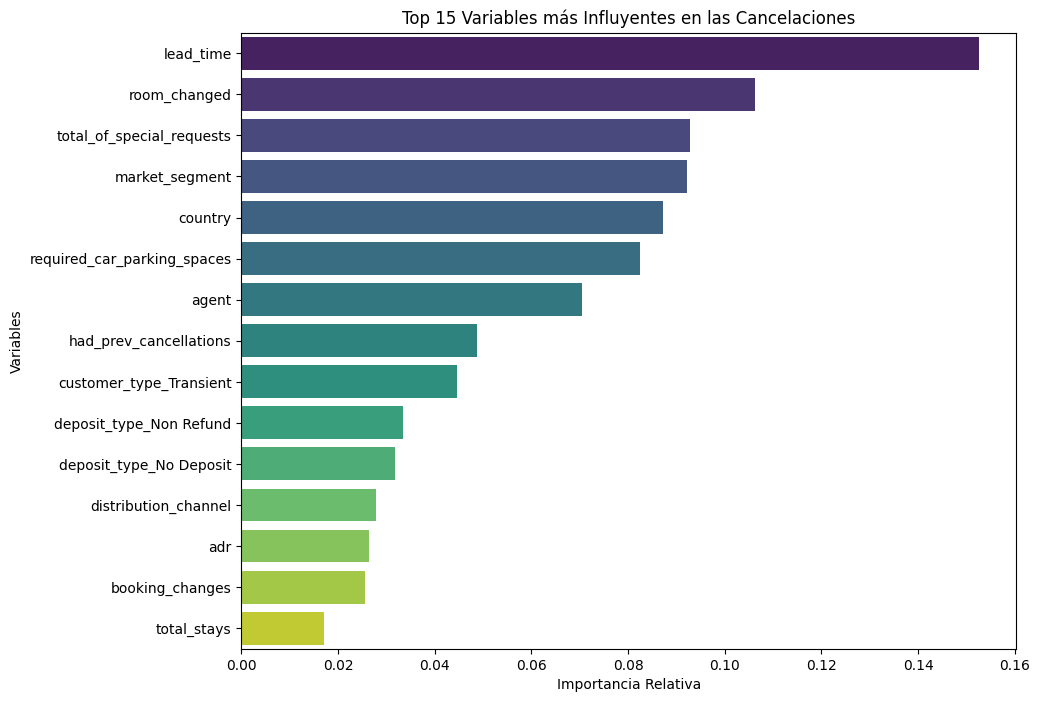

In [60]:
# 1. Extraer las importancias
# feature_importances_ es una propiedad del modelo que indica qué variables son las mas importantes para predecir.
importancias = rf_model.feature_importances_
#
# 2. Obtener los nombres de las columnas (X son variables de entrada)
nombres_columnas = X.columns

# 3. Crear un DataFrame para ordenar los datos
df_importancia = pd.DataFrame({'Variable': nombres_columnas, 'Importancia': importancias})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False)

# 4. Graficar
plt.figure(figsize=(10, 8))
sns.barplot(x='Importancia', y='Variable', data=df_importancia.head(15), palette='viridis')
plt.title('Top 15 Variables más Influyentes en las Cancelaciones')
plt.xlabel('Importancia Relativa')
plt.ylabel('Variables')
plt.show()

Modelo 3:  XGBoost

In [61]:
# 1. Creamos el modelo
xgb_model = XGBClassifier(
    n_estimators= 100,
    # Número total de árboles que construirá el modelo
    # Cada árbol intenta corregir errores del anterior
    scale_pos_weight= 2.6, 
     # Como el dataset está desbalanceado
    # (hay más "no cancelaciones" que "cancelaciones"),
    # este parámetro da más peso/importancia a la clase 1 (cancelaciones)
    # Ayuda a mejorar el recall de cancelaciones
    learning_rate= 0.1,
    # Controla cuánto aprende el modelo en cada árbol
    # Valores pequeños = aprendizaje más lento pero más estable
    max_depth= 6,
     # Árboles más profundos capturan patrones más complejos
    # Pero si son demasiado profundos puede haber overfitting
    random_state=42)# Fija la aleatoriedad del modelo
    # Permite obtener siempre los mismos resultados
    # al volver a ejecutar el código


In [62]:
#1. Ejecutamos la validación cruzada 
cv_xgb = cross_val_score(xgb_model, X_train, y_train, cv=5, scoring='recall')
# 2. Imprimimos (Media y Desviación)
print(f"Recall medio: {cv_xgb.mean():.4f}")
print(f"Desviación Estándar (Std): {cv_xgb.std():.4f}")
# La desviación estandar es mínima, esto nos indica que no hay overfitting. El modelo ha aprendido patrones reales y generaliza bien en datos nuevos.

Recall medio: 0.8692
Desviación Estándar (Std): 0.0082


--- MÉTRICAS DE XGBOOST ---
              precision    recall  f1-score   support

           0       0.94      0.78      0.85     12350
           1       0.60      0.87      0.71      4768

    accuracy                           0.80     17118
   macro avg       0.77      0.82      0.78     17118
weighted avg       0.84      0.80      0.81     17118



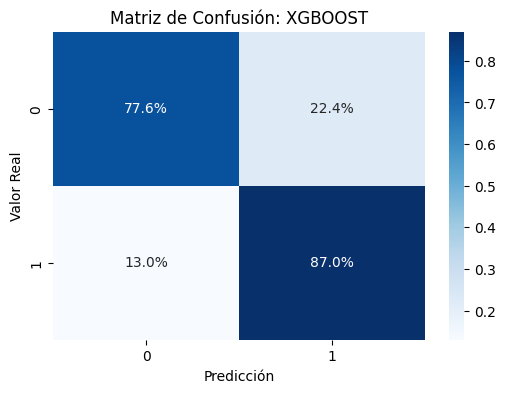

In [63]:
# 2. Entrenamos el modelo con datos de train
xgb_model.fit(X_train, y_train)

# 3. Realizamos las predicciones en test
y_pred_xgb = xgb_model.predict(X_test)
# 4. Métricas
print("--- MÉTRICAS DE XGBOOST ---")
print(classification_report(y_test, y_pred_xgb))

# 4. Matriz de Confusión
cm = confusion_matrix(y_test, y_pred_xgb, normalize='true')
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(cm,
            annot=True,
            fmt='.1%',
            cmap='Blues')
plt.title('Matriz de Confusión: XGBOOST')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

In [64]:
#  Sacar predicciones para ambos sets para controlar overfitting
y_pred_train = xgb_model.predict(X_train)
y_pred_test = xgb_model.predict(X_test)

# 2. Calcular el Accuracy para ambos
from sklearn.metrics import accuracy_score

train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)

print(f"Accuracy en Entrenamiento: {train_acc:.4f}")
print(f"Accuracy en Test: {test_acc:.4f}")
print(f"Diferencia: {train_acc - test_acc:.4f}")
# no se observa existencia de overfitting, el modelo aprende y generaliza bien en datos que no ha visto.

Accuracy en Entrenamiento: 0.8085
Accuracy en Test: 0.8019
Diferencia: 0.0066


Conclusión:<br>
1) El modelo es mucho más útil para el objetivo al que queremos llegar:<br>
Consigue detectar la mayoría de las cancelaciones reales(reduciendo el riesgo de habitaciones vacías no planificadas).<br>
2) El recall del 87%, significa que el modelo identifica correctamente la gran mayoría de clientes que cancelarán su reserva<br>
3) La precisión existe un 40% de "falsas alarmas", este margen es aceptabl, pues el coste de oportunidad de una habitación vacía suele ser mayor que el coste de realizar una acción de fidelización.<br>

4) El F1-score de 0.71 muestra un equilibrio razonable entre detectar cancelaciones y limitar errores.<br>


Feature importance XGBoost: ¿ qué variables variables son las más predictoras?

C:\Users\tifaw\AppData\Local\Temp\ipykernel_26788\2694359600.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=df_feat_imp.head(10), palette='magma')


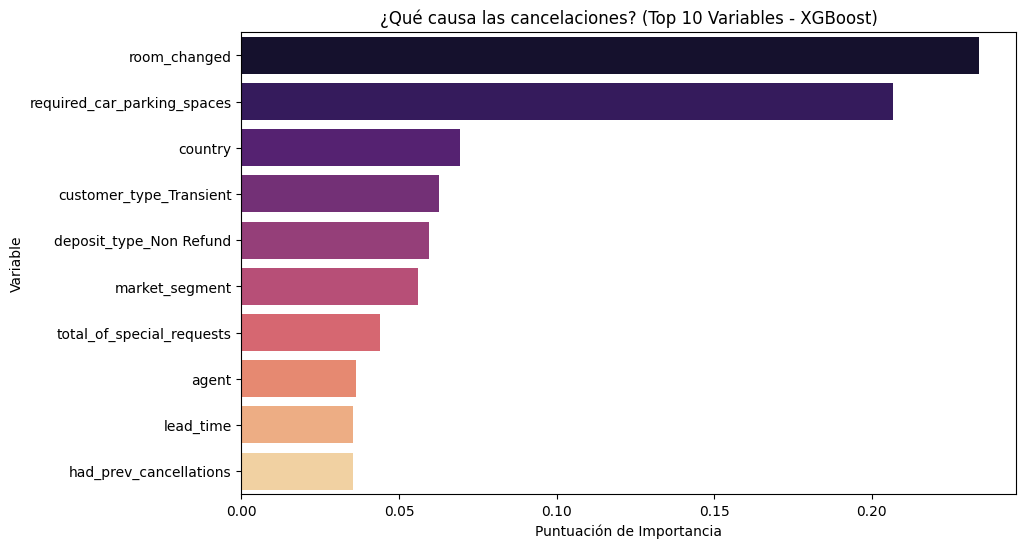

In [65]:
# 1. Extraer las importancias del modelo final
importancias = xgb_model.feature_importances_
nombres_columnas = X.columns # Asegúrate de que X sea el DataFrame con tus variables

# 2. Crear un DataFrame ordenado
df_feat_imp = pd.DataFrame({'Variable': nombres_columnas, 'Importancia': importancias})
df_feat_imp = df_feat_imp.sort_values(by='Importancia', ascending=False)

# 3. Graficar el Top 10
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=df_feat_imp.head(10), palette='magma')
plt.title('¿Qué causa las cancelaciones? (Top 10 Variables - XGBoost)')
plt.xlabel('Puntuación de Importancia')
plt.ylabel('Variable')
plt.show()

Comparación de Métricas en los 3 modelos

In [66]:

# 1. Creamos el diccionario con todos los resultados reales
data = {
    'Métrica': [
        'Accuracy (Global)',
        'Precision (Clase 1)',
        'Recall (Clase 1)',
        'F1-Score (Clase 1)',
        'Recall CV (Medio)',
        'Std CV (Estabilidad)'
    ],
    'Regresión Logística': [0.78, 0.71, 0.39, 0.50, None, None],
    'Random Forest': [0.81, 0.78, 0.45, 0.57, 0.4359, 0.0104],
    'XGBoost (Ganador)': [0.80, 0.60, 0.87, 0.71, 0.8692, 0.0082]
}

# 2. Creamos el DataFrame
df_resultados = pd.DataFrame(data)
df_resultados

,Métrica,Regresión Logística,Random Forest,XGBoost (Ganador)
0,Accuracy (Global),0.78,0.8100,0.8000
1,Precision (Clase 1),0.71,0.7800,0.6000
2,Recall (Clase 1),0.39,0.4500,0.8700
3,F1-Score (Clase 1),0.50,0.5700,0.7100
4,Recall CV (Medio),NaN,0.4359,0.8692
5,Std CV (Estabilidad),NaN,0.0104,0.0082


Guardar el modelo

In [71]:
import pickle

# Guardar el modelo XGBoost
import pickle

with open('modelo_final_hotel.pkl', "wb") as archivo_salida:
    pickle.dump(xgb_model, archivo_salida)
    
# 2. Guardar el escalador( importante para procesar datos nuevos)
with open('escalador_hotel.pkl', 'wb') as archivo_escalador:
    pickle.dump(scaler, archivo_escalador)
    
print("Archivos guardados correctamente con Pickle: Modelo y Escalador")

Archivos guardados correctamente con Pickle: Modelo y Escalador


In [74]:
# 3. Guardar la lista de columnas (para mantener siempre el mismo orden)
with open('columnas_modelo_final_hotel.pkl', 'wb') as archivo_columnas:
    pickle.dump(X.columns.tolist(), archivo_columnas)

print("Archivos guardados correctamente con Pickle: Columnas.")

Archivos guardados correctamente con Pickle: Columnas.
